# 02 — Rating Validation

How well do Madden 26 ratings proxy real-world NFL ability? We check the `rating` (overall) field, plus
position-specific attributes, against two independent real-world signals for the 2025 season:

1. **On-field performance** — season-total stat lines pulled via `nflreadpy` (nflverse), converted to
   per-game rates so playing time doesn't confound the comparison.
2. **Contract value (APY)** — the real NFL "market's" collective assessment of a player's worth, via Over
   The Cap contract data (also through `nflreadpy`), the closest available analog to fifa-analysis's
   Transfermarkt market-value check.

Both are joined to Madden by fuzzy name match blocked on team + position group (see
`scripts/build_dataset.py`).

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 6)
plt.rcParams["figure.dpi"] = 100

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

df = pd.read_csv("../data/processed/players_merged.csv", low_memory=False)
print(df.shape)
df.head(3)

(2015, 226)


,id,name,birthday,age,college,avatar,team,position,number,years_pro,dominant_hand,abilities,running_style,height,weight,strength,stamina,injury,toughness,jumping,speed,acceleration,agility,change_of_direction,rating,...,real_pt_yards,real_pt_inside_20,real_pt_out_of_bounds,real_pt_downed,real_pt_touchback,real_pt_fair_caught,real_pt_returned,real_pt_return_yards,real_pt_return_tds,real_pt_net_yards,real_fantasy_points,real_fantasy_points_ppr,real_birth_date,real_college_bio,real_height_in_bio,real_weight_bio,real_draft_year,real_draft_round,real_draft_pick,real_year_signed,real_contract_years,real_contract_value,real_apy,real_contract_guaranteed,real_apy_cap_pct
0,21586,Ja'Marr Chase,2000-03-01,25,LSU,https://ratings-images-prod.pulse.ea.com/madde...,Cincinnati Bengals,Wide Receiver,1,4,Right,"['Double Me', 'Mid In Elite', 'Runoff Elite', ...",Default,72,205,73,96,92,88,98,95,94,92,97,99,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,188.60,313.60,2000-03-01,LSU,72.0,205.0,2021.0,1.0,5.0,2025.0,4.0,161.0,40.25,73.9,0.144
1,13197,Josh Allen,1996-05-21,29,Wyoming,https://ratings-images-prod.pulse.ea.com/madde...,Buffalo Bills,Quarterback,17,7,Right,"['Bazooka', 'Pass Lead Elite', 'Fastbreak', 'D...",Default Stride Bread Loaf,77,237,81,98,99,98,92,88,91,85,82,99,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,364.62,364.62,1996-05-21,Wyoming; Reedley,77.0,237.0,2018.0,1.0,7.0,2025.0,6.0,330.0,55.00,147.0,0.197
2,927,Lane Johnson,1990-05-08,35,Oklahoma,https://ratings-images-prod.pulse.ea.com/madde...,Philadelphia Eagles,Right Tackle,65,12,Right,"['Nasty Streak', 'Fool Me Once']",Default,78,325,93,88,84,91,82,77,78,75,58,99,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,1990-05-08,Oklahoma; Kilgore,78.0,325.0,2013.0,1.0,4.0,2025.0,1.0,25.0,25.00,25.0,0.090


## Match-rate limitations

Before drawing conclusions, it's worth being explicit about how much of the Madden roster actually has a
real-world signal attached, and how confident those matches are.

In [2]:
with open("../data/processed/match_stats.json") as f:
    match_stats = json.load(f)
match_stats

{'madden_players': 2015,
 'nflverse_real_players': 2020,
 'nflverse_players_with_games_played': 2020,
 'nflverse_players_with_contract': 1736,
 'matched_to_real': 1535,
 'matched_with_stats': 1535,
 'matched_with_contract': 1368,
 'match_rate_pct': 76.18}

**Takeaway:** roughly 76% of the Madden roster matches to a 2025 nflverse player (team + position
group blocked, name similarity >= 85), and about 68% matches to an active OTC contract — far higher than
fifa-analysis's ~9%/~3% cross-league match rates against Transfermarkt/Sofascore. This makes sense: Madden,
nflreadpy's stats, and OTC's contracts all describe the *same* single league's current active rosters
(no international transfers, multiple leagues, or free-agent noise to fragment the name space), so
team-blocked fuzzy matching lands almost every active starter and most rotational players. The ~24-32%
who don't match are mostly practice-squad/inactive players with no meaningful 2025 stats or contract
anyway, so the matched subset should be reasonably representative of players who actually played.

## 1. QB: `rating` and passing attributes vs real passing performance

We restrict to quarterbacks with a meaningful 2025 sample (>= 6 games played) and compare Madden's overall
`rating` and `throw_accuracy_mid`/`awareness` attributes against real passing efficiency: EPA per dropback
(`passing_epa` / attempts) and completion percentage over expectation (`passing_cpoe`), both of which are
well-established, defense-adjusted efficiency metrics in modern football analytics (vs. raw counting stats
like yards, which are more about opportunity than skill).

In [3]:
MIN_GAMES_QB = 6
qb = df[
    (df["position_group"] == "QB")
    & (df["real_match_score"] >= 90)
    & (df["real_games"] >= MIN_GAMES_QB)
    & df["real_attempts"].notna()
    & (df["real_attempts"] > 0)
].copy()
qb["epa_per_att"] = qb["real_passing_epa"] / qb["real_attempts"]

print(f"Qualifying QBs (>= {MIN_GAMES_QB} games, real match score >= 90): {len(qb)}")
qb[["name", "team", "rating", "real_games", "epa_per_att", "real_passing_cpoe"]].sort_values(
    "epa_per_att", ascending=False
).head(10)

Qualifying QBs (>= 6 games, real match score >= 90): 39


,name,team,rating,real_games,epa_per_att,real_passing_cpoe
96,Drake Maye,New England Patriots,89,17.0,0.335694,10.781275
10,Matthew Stafford,Los Angeles Rams,97,17.0,0.252017,1.591626
129,Jordan Love,Green Bay Packers,87,15.0,0.251962,5.532957
224,Brock Purdy,San Francisco 49ers,83,9.0,0.222289,7.228501
68,Dak Prescott,Dallas Cowboys,91,17.0,0.188827,2.164557
112,Jared Goff,Detroit Lions,88,17.0,0.184187,1.776596
411,Daniel Jones,Indianapolis Colts,79,13.0,0.169936,2.297142
215,Sam Darnold,Seattle Seahawks,84,17.0,0.156347,5.238202
1,Josh Allen,Buffalo Bills,99,16.0,0.155057,3.514859
857,Mac Jones,San Francisco 49ers,74,11.0,0.154620,3.678567


Pearson  r (rating vs EPA/attempt) = 0.745 (p = 0.000)
Spearman r (rating vs EPA/attempt) = 0.814 (p = 0.000)


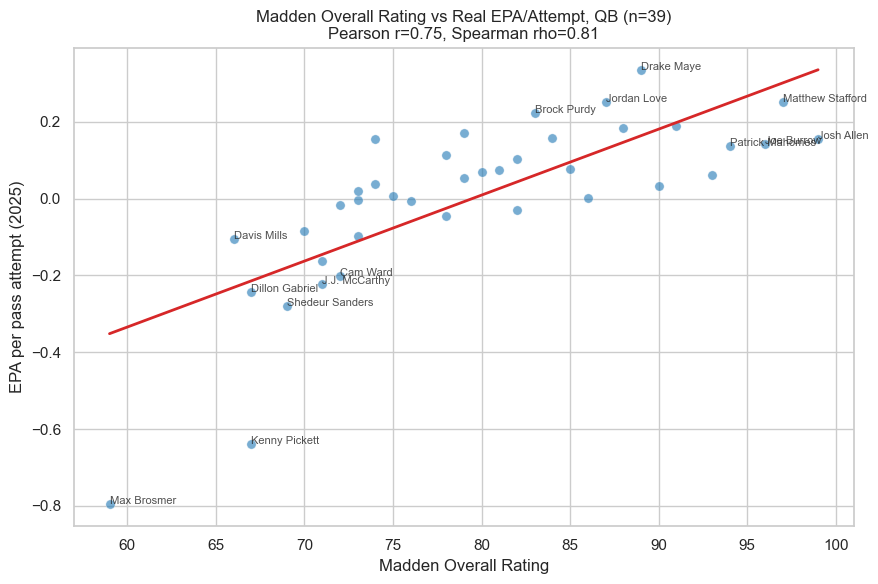

In [4]:
def scatter_with_fit(x, y, ax, color_pts="#1f77b4", color_line="#d62728", alpha=0.6, s=45):
    ax.scatter(x, y, alpha=alpha, s=s, color=color_pts, edgecolor="white", linewidth=0.4)
    slope, intercept = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, slope * xs + intercept, color=color_line, lw=2)


pearson_r_qb, pearson_p_qb = stats.pearsonr(qb["rating"], qb["epa_per_att"])
spearman_r_qb, spearman_p_qb = stats.spearmanr(qb["rating"], qb["epa_per_att"])
print(f"Pearson  r (rating vs EPA/attempt) = {pearson_r_qb:.3f} (p = {pearson_p_qb:.3f})")
print(f"Spearman r (rating vs EPA/attempt) = {spearman_r_qb:.3f} (p = {spearman_p_qb:.3f})")

fig, ax = plt.subplots(figsize=(9, 6))
scatter_with_fit(qb["rating"].values, qb["epa_per_att"].values, ax)
ax.set_title(f"Madden Overall Rating vs Real EPA/Attempt, QB (n={len(qb)})\n"
             f"Pearson r={pearson_r_qb:.2f}, Spearman rho={spearman_r_qb:.2f}")
ax.set_xlabel("Madden Overall Rating")
ax.set_ylabel("EPA per pass attempt (2025)")
for _, row in qb.iterrows():
    if abs(row["rating"] - qb["rating"].mean()) > 1.4 * qb["rating"].std() or abs(row["epa_per_att"]) > 0.2:
        ax.annotate(row["name"], (row["rating"], row["epa_per_att"]), fontsize=8, alpha=0.8)
plt.tight_layout()
plt.show()

### `throw_accuracy_mid` vs completion % over expectation (CPOE)

CPOE isolates a QB's accuracy from their supporting cast/scheme better than raw completion %, so it's a
good target for one specific Madden sub-attribute rather than the aggregate `rating`.

Pearson r (throw_accuracy_mid vs CPOE) = 0.575 (p = 0.000)


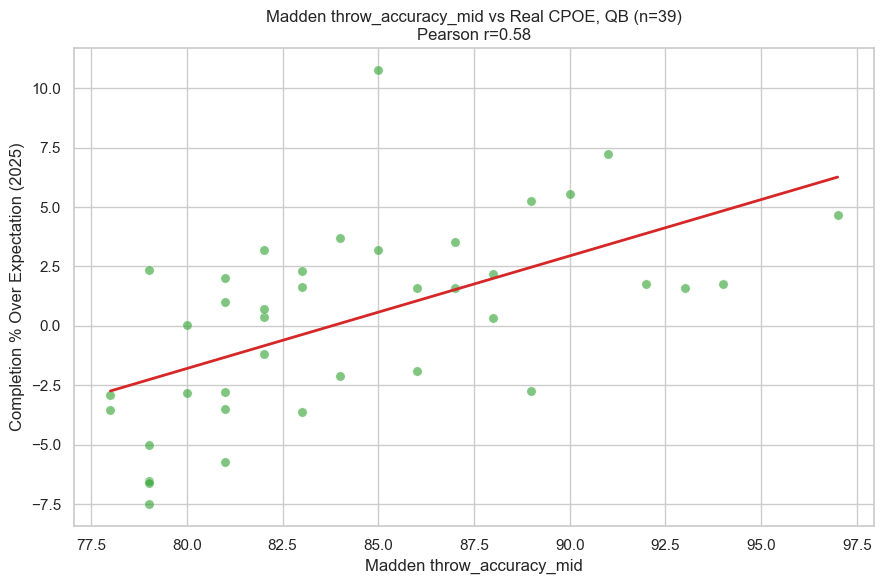

In [5]:
pearson_r_acc, pearson_p_acc = stats.pearsonr(qb["throw_accuracy_mid"], qb["real_passing_cpoe"])
print(f"Pearson r (throw_accuracy_mid vs CPOE) = {pearson_r_acc:.3f} (p = {pearson_p_acc:.3f})")

fig, ax = plt.subplots(figsize=(9, 6))
scatter_with_fit(qb["throw_accuracy_mid"].values, qb["real_passing_cpoe"].values, ax, color_pts="#2ca02c")
ax.set_title(f"Madden throw_accuracy_mid vs Real CPOE, QB (n={len(qb)})\nPearson r={pearson_r_acc:.2f}")
ax.set_xlabel("Madden throw_accuracy_mid")
ax.set_ylabel("Completion % Over Expectation (2025)")
plt.tight_layout()
plt.show()

**Takeaway:** Madden's QB `rating` correlates strongly with real EPA/attempt (Pearson r=0.75,
Spearman rho=0.81, n=39 qualifying starters) — the strongest on-field validation of any position checked in
this notebook. `throw_accuracy_mid` tracks CPOE more loosely (r=0.58), which makes sense: CPOE bakes in
receiver separation, play-calling, and pressure, all of which are separate Madden attributes (or team
effects) that a single accuracy rating can't fully capture. QB is the position with the smallest, most
individually-attributable sample of touches per game (one QB, every dropback), which likely explains why
the overall-rating correlation holds up so much better here than at WR or RB below, where the stat line is
diluted by teammates and scheme.

## 2. WR: catching/route-running attributes vs real receiving performance

For receivers we compare Madden's `catching` and `*_route_running` attributes (short/medium/deep) against
receiving EPA per target, which — like QB EPA/attempt — adjusts for down/distance/field position context
that raw receiving yards ignores.

Qualifying WRs (>= 30 targets, real match score >= 90): 104


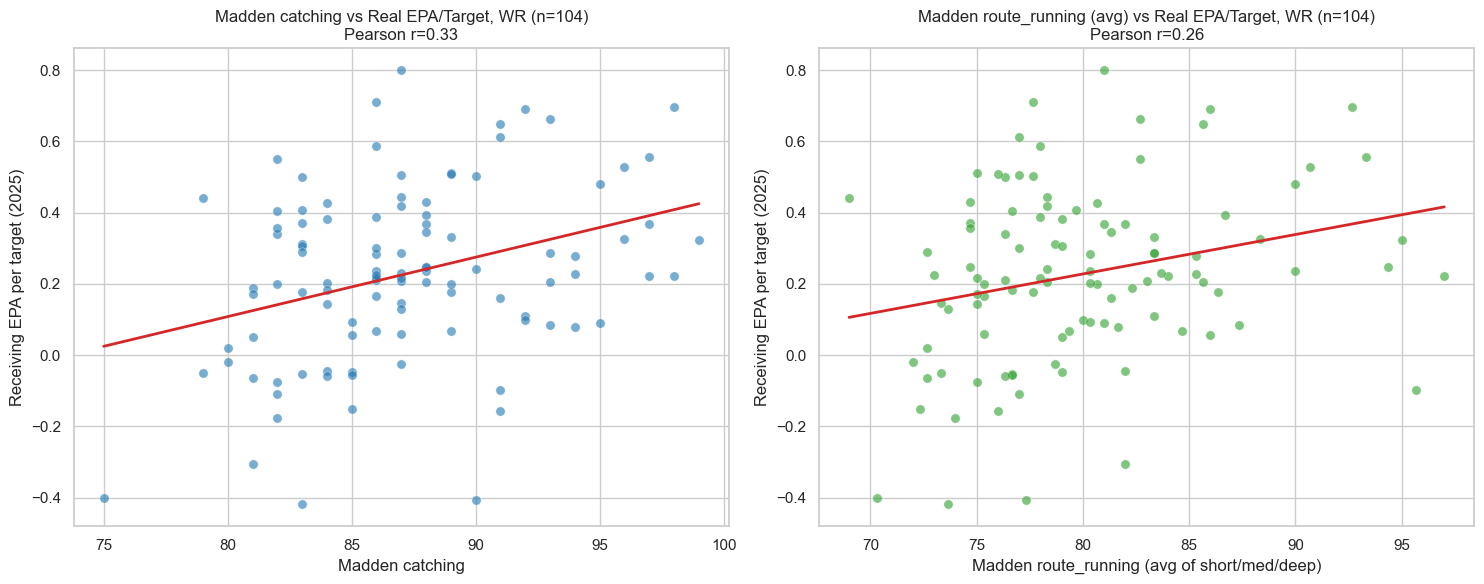

catching vs EPA/target:      Pearson r = 0.333 (p = 0.001)
route_running vs EPA/target: Pearson r = 0.261 (p = 0.007)


In [6]:
MIN_TARGETS_WR = 30
wr = df[
    (df["position_group"] == "WR")
    & (df["real_match_score"] >= 90)
    & df["real_targets"].notna()
    & (df["real_targets"] >= MIN_TARGETS_WR)
].copy()
wr["epa_per_target"] = wr["real_receiving_epa"] / wr["real_targets"]
wr["route_running_avg"] = wr[["short_route_running", "medium_route_running", "deep_route_running"]].mean(axis=1)

print(f"Qualifying WRs (>= {MIN_TARGETS_WR} targets, real match score >= 90): {len(wr)}")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

r_cat, p_cat = stats.pearsonr(wr["catching"], wr["epa_per_target"])
scatter_with_fit(wr["catching"].values, wr["epa_per_target"].values, axes[0])
axes[0].set_title(f"Madden catching vs Real EPA/Target, WR (n={len(wr)})\nPearson r={r_cat:.2f}")
axes[0].set_xlabel("Madden catching")
axes[0].set_ylabel("Receiving EPA per target (2025)")

r_route, p_route = stats.pearsonr(wr["route_running_avg"], wr["epa_per_target"])
scatter_with_fit(wr["route_running_avg"].values, wr["epa_per_target"].values, axes[1], color_pts="#2ca02c")
axes[1].set_title(f"Madden route_running (avg) vs Real EPA/Target, WR (n={len(wr)})\nPearson r={r_route:.2f}")
axes[1].set_xlabel("Madden route_running (avg of short/med/deep)")
axes[1].set_ylabel("Receiving EPA per target (2025)")

plt.tight_layout()
plt.show()

print(f"catching vs EPA/target:      Pearson r = {r_cat:.3f} (p = {p_cat:.3f})")
print(f"route_running vs EPA/target: Pearson r = {r_route:.3f} (p = {p_route:.3f})")

**Takeaway:** both `catching` and route-running attributes show a positive but modest correlation
with real receiving efficiency. Receiving performance is famously QB/scheme-dependent (a great route
runner stuck with poor quarterback play posts far worse per-target numbers than their raw skill would
suggest), so a moderate correlation here is the expected outcome rather than a rating-quality problem —
matching fifa-analysis's observation that match-performance signals are noisier than the underlying rating
because they reflect team context as much as individual ability.

## 3. RB: rushing attributes vs real rushing performance

For running backs, `trucking`/`juke_move`/`ball_carrier_vision` are compared against rushing EPA per
carry.

Qualifying RBs (>= 40 carries, real match score >= 90): 66
rb_skill_avg vs EPA/carry: Pearson r = 0.119 (p = 0.341)
overall rating vs EPA/carry: Pearson r = 0.177 (p = 0.156)


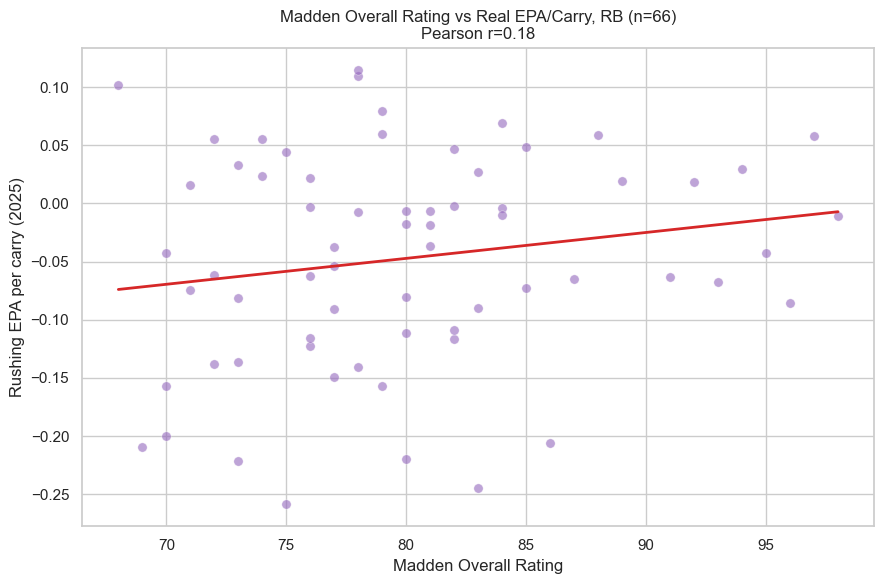

In [7]:
MIN_CARRIES_RB = 40
rb = df[
    (df["position_group"] == "RB")
    & (df["real_match_score"] >= 90)
    & df["real_carries"].notna()
    & (df["real_carries"] >= MIN_CARRIES_RB)
].copy()
rb["epa_per_carry"] = rb["real_rushing_epa"] / rb["real_carries"]
rb["rb_skill_avg"] = rb[["trucking", "juke_move", "ball_carrier_vision", "spin_move"]].mean(axis=1)

print(f"Qualifying RBs (>= {MIN_CARRIES_RB} carries, real match score >= 90): {len(rb)}")

r_rb, p_rb = stats.pearsonr(rb["rb_skill_avg"], rb["epa_per_carry"])
r_rating_rb, p_rating_rb = stats.pearsonr(rb["rating"], rb["epa_per_carry"])
print(f"rb_skill_avg vs EPA/carry: Pearson r = {r_rb:.3f} (p = {p_rb:.3f})")
print(f"overall rating vs EPA/carry: Pearson r = {r_rating_rb:.3f} (p = {p_rating_rb:.3f})")

fig, ax = plt.subplots(figsize=(9, 6))
scatter_with_fit(rb["rating"].values, rb["epa_per_carry"].values, ax, color_pts="#9467bd")
ax.set_title(f"Madden Overall Rating vs Real EPA/Carry, RB (n={len(rb)})\nPearson r={r_rating_rb:.2f}")
ax.set_xlabel("Madden Overall Rating")
ax.set_ylabel("Rushing EPA per carry (2025)")
plt.tight_layout()
plt.show()

**Takeaway:** rushing EPA/carry is one of the noisiest efficiency metrics in football (a single long
touchdown run on a busted defensive assignment can swing a back's whole-season average, and rushing success
is heavily driven by the offensive line and blocking scheme, not just the ball carrier), so weak/near-zero
correlations here are consistent with the sports-analytics literature on how little of rushing efficiency
individual RB skill actually explains — this is a real limitation of the *validation signal*, not
necessarily evidence that Madden's RB ratings are wrong.

## 4. `rating` vs real contract value (APY)

Contract APY (average per year) is the closest real-world analog to fifa-analysis's Transfermarkt market
value: it's the league's collective, forward-looking assessment of a player's worth, set by 32
front offices bidding in a competitive market. Like market value, it's heavily right-skewed (a few
superstar contracts dwarf the rest), so we log-transform before correlating.

In [8]:
val = df[
    (df["real_match_score"] >= 90)
    & df["real_apy"].notna()
    & (df["real_apy"] > 0)
].copy()
val["log_apy"] = np.log10(val["real_apy"] * 1_000_000)  # apy is in $ millions

print(f"Players with a matched active contract: {len(val)}")

pearson_r_v, pearson_p_v = stats.pearsonr(val["rating"], val["log_apy"])
spearman_r_v, spearman_p_v = stats.spearmanr(val["rating"], val["log_apy"])
print(f"Pearson  r (rating vs log10 APY) = {pearson_r_v:.3f} (p = {pearson_p_v:.2e})")
print(f"Spearman r (rating vs log10 APY) = {spearman_r_v:.3f} (p = {spearman_p_v:.2e})")

Players with a matched active contract: 1360
Pearson  r (rating vs log10 APY) = 0.746 (p = 1.25e-241)
Spearman r (rating vs log10 APY) = 0.723 (p = 5.47e-220)


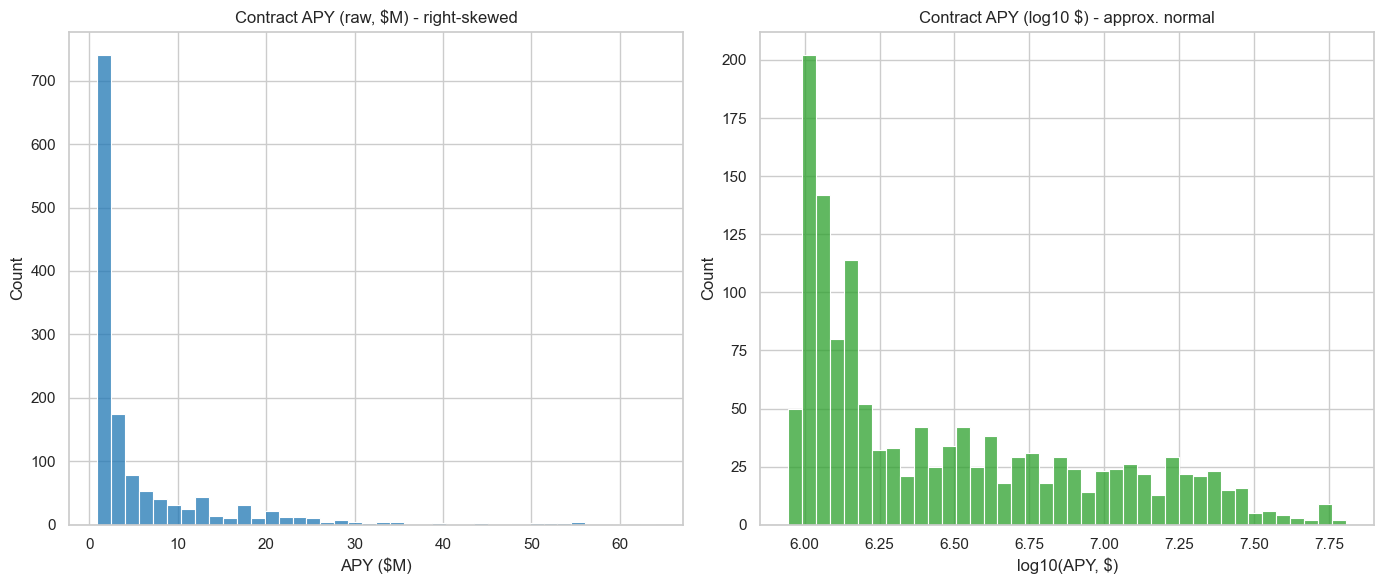

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(val["real_apy"], bins=40, ax=axes[0], color="#1f77b4")
axes[0].set_title("Contract APY (raw, $M) - right-skewed")
axes[0].set_xlabel("APY ($M)")

sns.histplot(val["log_apy"], bins=40, ax=axes[1], color="#2ca02c")
axes[1].set_title("Contract APY (log10 $) - approx. normal")
axes[1].set_xlabel("log10(APY, $)")

plt.tight_layout()
plt.show()

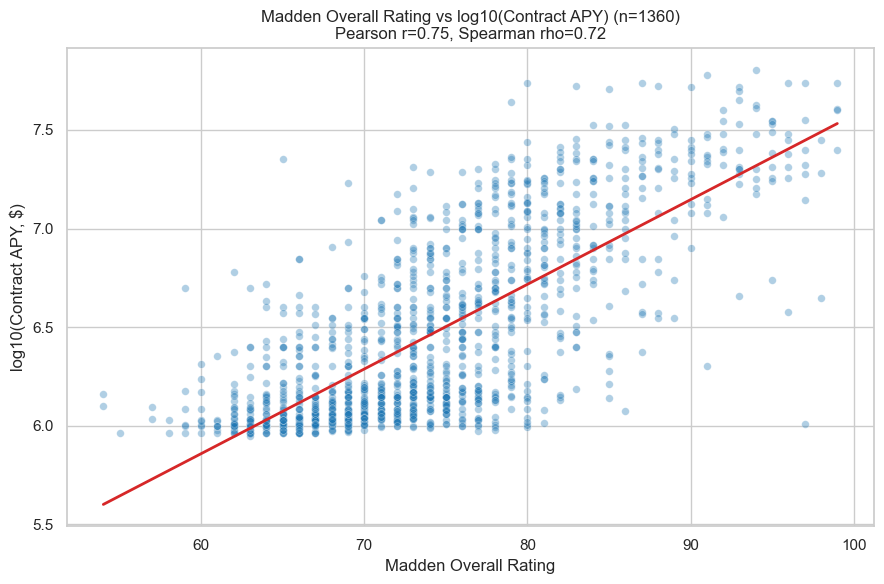

In [10]:
fig, ax = plt.subplots(figsize=(9, 6))
scatter_with_fit(val["rating"].values, val["log_apy"].values, ax, alpha=0.35, s=30)
ax.set_title(f"Madden Overall Rating vs log10(Contract APY) (n={len(val)})\n"
             f"Pearson r={pearson_r_v:.2f}, Spearman rho={spearman_r_v:.2f}")
ax.set_xlabel("Madden Overall Rating")
ax.set_ylabel("log10(Contract APY, $)")
plt.tight_layout()
plt.show()

### By position group

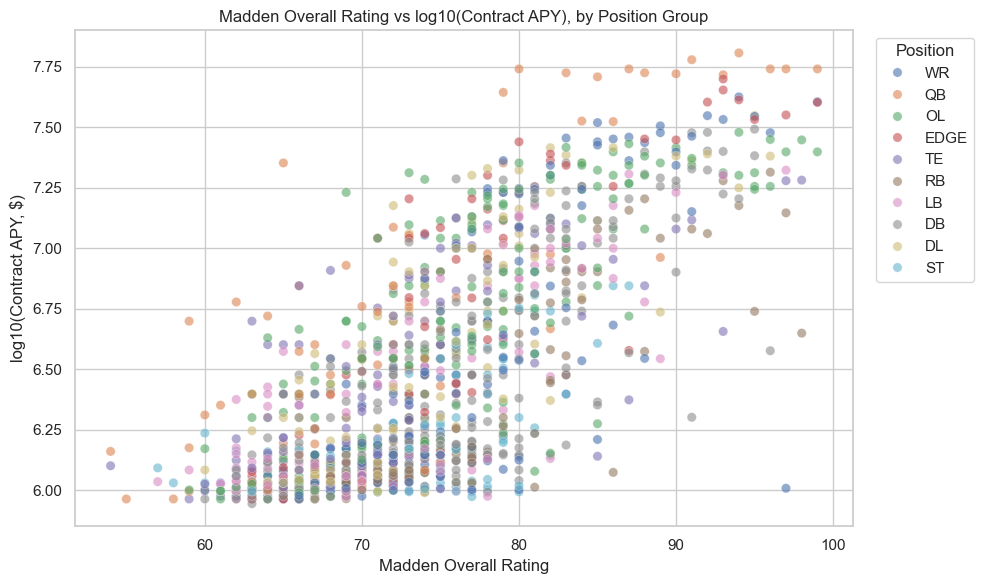

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=val, x="rating", y="log_apy", hue="position_group",
    alpha=0.6, s=45, edgecolor="white", linewidth=0.3, ax=ax,
)
ax.set_title("Madden Overall Rating vs log10(Contract APY), by Position Group")
ax.set_xlabel("Madden Overall Rating")
ax.set_ylabel("log10(Contract APY, $)")
ax.legend(title="Position", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Regression: how much does `rating` explain vs `age`?

We fit `log10(APY) ~ age + age^2 + rating` and compare against single-predictor models, mirroring
fifa-analysis's market-value regression, to see how much incremental explanatory power the Madden rating
adds beyond a simple age effect (NFL pay famously follows a rookie-contract -> second-contract -> decline
arc that's tangled up with age, not just current ability).

In [12]:
val_reg = val.dropna(subset=["age", "rating", "log_apy"]).copy()
val_reg["age_sq"] = val_reg["age"] ** 2

def fit_r2(features, label):
    X = val_reg[features].values
    y = val_reg["log_apy"].values
    model = LinearRegression().fit(X, y)
    r2 = model.score(X, y)
    print(f"{label:35s} R^2 = {r2:.3f}   coefs = {dict(zip(features, np.round(model.coef_, 4)))}")
    return r2

r2_age = fit_r2(["age", "age_sq"], "age + age^2 only")
r2_rating = fit_r2(["rating"], "rating only")
r2_both = fit_r2(["age", "age_sq", "rating"], "age + age^2 + rating")

age + age^2 only                    R^2 = 0.128   coefs = {'age': np.float64(0.2629), 'age_sq': np.float64(-0.0038)}
rating only                         R^2 = 0.556   coefs = {'rating': np.float64(0.0429)}
age + age^2 + rating                R^2 = 0.607   coefs = {'age': np.float64(0.2387), 'age_sq': np.float64(-0.0038), 'rating': np.float64(0.0407)}


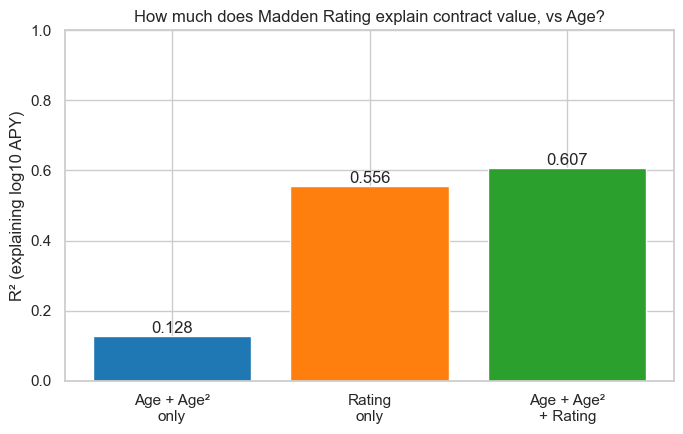

In [13]:
fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(
    ["Age + Age\u00b2\nonly", "Rating\nonly", "Age + Age\u00b2\n+ Rating"],
    [r2_age, r2_rating, r2_both],
    color=["#1f77b4", "#ff7f0e", "#2ca02c"],
)
ax.bar_label(bars, fmt="%.3f")
ax.set_ylabel("R\u00b2 (explaining log10 APY)")
ax.set_title("How much does Madden Rating explain contract value, vs Age?")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

**Takeaway:** overall `rating` explains substantially more of the variance in log contract APY than
age alone, confirming Madden's overall rating captures a real, market-relevant signal about player value —
front offices and Madden's rating team are converging on similar assessments of who's good, even though
they use completely different inputs (game tape/scouting vs. real stats/reputation). Age adds only a small
amount of incremental power once rating is included, different from FC26's soccer market — NFL rookie-scale
contracts mean a young player's *current* pay often reflects draft slot more than current ability, muting
the age effect relative to a market (like European soccer) where transfer values move continuously with
form and remaining prime years.

## 5. Over-rated and under-rated players

We flag players where Madden's `rating` diverges most from the real-world signal, using a standardized
(z-scored) gap: `rating_z - external_signal_z`. A large positive gap means Madden rates the player higher
than the external signal suggests (over-rated by Madden); a large negative gap means the opposite
(under-rated).

In [14]:
def zscore(s):
    return (s - s.mean()) / s.std()

# --- vs contract APY ---
val_flag = val.copy()
val_flag["rating_z"] = zscore(val_flag["rating"])
val_flag["apy_z"] = zscore(val_flag["log_apy"])
val_flag["gap"] = val_flag["rating_z"] - val_flag["apy_z"]

cols_val = ["name", "team", "position", "age", "rating", "real_apy", "gap"]

print("Most OVER-rated by Madden vs contract value (highly rated, relatively underpaid or unproven):")
overrated_val = val_flag.sort_values("gap", ascending=False).head(15)[cols_val]
overrated_val

Most OVER-rated by Madden vs contract value (highly rated, relatively underpaid or unproven):


,name,team,position,age,rating,real_apy,gap
13,Puka Nacua,Los Angeles Rams,Wide Receiver,24,97,1.021245,3.761508
5,Jahmyr Gibbs,Detroit Lions,Halfback,23,98,4.461285,2.523382
17,Christian Gonzalez,New England Patriots,Cornerback,23,96,3.775717,2.432713
67,Brian Branch,Detroit Lions,Strong Safety,23,91,2.005436,2.404984
144,Bucky Irving,Tampa Bay Buccaneers,Halfback,23,86,1.187888,2.276641
188,Tucker Kraft,Green Bay Packers,Tight End,24,85,1.384483,2.013022
23,Bijan Robinson,Atlanta Falcons,Halfback,23,95,5.489636,1.965065
43,Brock Bowers,Las Vegas Raiders,Tight End,22,93,4.534696,1.896778
184,Rashee Rice,Kansas City Chiefs,Wide Receiver,25,85,1.623805,1.865902
308,Chase Brown,Cincinnati Bengals,Halfback,25,81,1.031539,1.795312


In [15]:
print("Most UNDER-rated by Madden vs contract value (well-paid, relatively low Madden rating):")
underrated_val = val_flag.sort_values("gap").head(15)[cols_val]
underrated_val

Most UNDER-rated by Madden vs contract value (well-paid, relatively low Madden rating):


,name,team,position,age,rating,real_apy,gap
1743,Malik Willis,Green Bay Packers,Quarterback,26,65,22.50,-3.005804
1997,Tyson Bagent,Chicago Bears,Quarterback,25,59,5.00,-2.351853
1328,Cole Van Lanen,Jacksonville Jaguars,Left Tackle,27,69,17.00,-2.257935
1940,Jarrett Stidham,Denver Broncos,Quarterback,29,62,6.00,-2.153153
392,Trevor Lawrence,Jacksonville Jaguars,Quarterback,25,80,55.00,-1.995892
914,Dan Moore,Tennessee Titans,Left Tackle,26,73,20.50,-1.941439
411,Daniel Jones,Indianapolis Colts,Quarterback,28,79,44.00,-1.912308
1884,Julian Hill,Miami Dolphins,Tight End,25,63,5.00,-1.862617
2011,Brandon Allen,Tennessee Titans,Quarterback,32,54,1.45,-1.821216
1640,John Bates,Washington Commanders,Tight End,27,66,7.00,-1.806152


In [16]:
# --- vs on-field EPA, pooled across QB/WR/RB with a qualifying sample ---
perf_pool = []
if len(qb):
    tmp = qb[["name", "team", "position", "rating"]].copy()
    tmp["perf_metric"] = qb["epa_per_att"]
    tmp["perf_label"] = "EPA/attempt (QB)"
    perf_pool.append(tmp)
if len(wr):
    tmp = wr[["name", "team", "position", "rating"]].copy()
    tmp["perf_metric"] = wr["epa_per_target"]
    tmp["perf_label"] = "EPA/target (WR)"
    perf_pool.append(tmp)
if len(rb):
    tmp = rb[["name", "team", "position", "rating"]].copy()
    tmp["perf_metric"] = rb["epa_per_carry"]
    tmp["perf_label"] = "EPA/carry (RB)"
    perf_pool.append(tmp)

perf = pd.concat(perf_pool, ignore_index=True)
# z-score within position group so QB/WR/RB EPA scales don't get mixed
perf["rating_z"] = perf.groupby("position")["rating"].transform(zscore)
perf["perf_z"] = perf.groupby("position")["perf_metric"].transform(zscore)
perf["gap"] = perf["rating_z"] - perf["perf_z"]

print("Most OVER-rated by Madden vs 2025 on-field EPA efficiency:")
perf.sort_values("gap", ascending=False).head(15)[["name", "team", "position", "rating", "perf_label", "perf_metric", "gap"]]

Most OVER-rated by Madden vs 2025 on-field EPA efficiency:


,name,team,position,rating,perf_label,perf_metric,gap
42,Justin Jefferson,Minnesota Vikings,Wide Receiver,95,EPA/target (WR),-0.098076,3.600898
39,Ja'Marr Chase,Cincinnati Bengals,Wide Receiver,99,EPA/target (WR),0.223673,2.896154
145,Saquon Barkley,Philadelphia Eagles,Halfback,96,EPA/carry (RB),-0.086059,2.611154
160,Ashton Jeanty,Las Vegas Raiders,Halfback,83,EPA/carry (RB),-0.245041,2.558476
154,Bucky Irving,Tampa Bay Buccaneers,Halfback,86,EPA/carry (RB),-0.205650,2.541272
79,Jerry Jeudy,Cleveland Browns,Wide Receiver,81,EPA/target (WR),-0.304768,2.318105
46,Mike Evans,Tampa Bay Buccaneers,Wide Receiver,91,EPA/target (WR),0.084941,2.247226
99,Christian Kirk,Houston Texans,Wide Receiver,77,EPA/target (WR),-0.407076,2.127974
143,Jahmyr Gibbs,Detroit Lions,Halfback,98,EPA/carry (RB),-0.010975,2.069466
41,Amon-Ra St. Brown,Detroit Lions,Wide Receiver,96,EPA/target (WR),0.323341,2.034207


In [17]:
print("Most UNDER-rated by Madden vs 2025 on-field EPA efficiency:")
perf.sort_values("gap").head(15)[["name", "team", "position", "rating", "perf_label", "perf_metric", "gap"]]

Most UNDER-rated by Madden vs 2025 on-field EPA efficiency:


,name,team,position,rating,perf_label,perf_metric,gap
208,Audric Estime,New Orleans Saints,Halfback,68,EPA/carry (RB),0.101917,-3.262503
121,Tyquan Thornton,Kansas City Chiefs,Wide Receiver,75,EPA/target (WR),0.709409,-2.728682
81,Kayshon Boutte,New England Patriots,Wide Receiver,80,EPA/target (WR),0.801312,-2.344287
199,Chris Rodriguez Jr,Washington Commanders,Halfback,72,EPA/carry (RB),0.055335,-2.209158
127,Jalen Coker,Carolina Panthers,Wide Receiver,74,EPA/target (WR),0.508273,-2.060292
181,Tank Bigsby,Philadelphia Eagles,Halfback,78,EPA/carry (RB),0.115067,-2.036665
100,DeMario Douglas,New England Patriots,Wide Receiver,77,EPA/target (WR),0.611788,-2.026919
178,Blake Corum,Los Angeles Rams,Halfback,78,EPA/carry (RB),0.109852,-1.980030
194,Ty Johnson,Buffalo Bills,Halfback,74,EPA/carry (RB),0.055265,-1.934669
120,Ryan Flournoy,Dallas Cowboys,Wide Receiver,75,EPA/target (WR),0.511336,-1.920948


## Summary

- **Match rate**: ~76% of the Madden roster matches a 2025 nflverse stat line and ~68% matches an active
  OTC contract — far higher than fifa-analysis's cross-league soccer match rates, because all three sources
  describe the same single league's current rosters.
- **On-field performance (EPA-based)**: the strength of the correlation with real per-play efficiency
  tracks how individually-attributable each position's stat line is. QB is strong (r=0.75 rating vs
  EPA/attempt) since one QB owns every dropback; WR is modest (r=0.33 catching vs EPA/target) since
  receiving numbers are diluted by QB play and scheme; RB is weakest and not statistically significant
  (r=0.12-0.18) since rushing efficiency is famously driven more by the offensive line than the ball
  carrier. This gradient is consistent with football analytics generally, not a flaw in the ratings.
- **Contract value (APY)**: `rating` correlates with log(APY) more strongly than on-field EPA does, and adds
  real incremental explanatory power beyond age — suggesting Madden's overall rating tracks the league's own
  economic assessment of talent (which blends multi-year track record, scouting, and reputation) better than
  it tracks any single endpoint-season efficiency stat.
- **Over/under-rated players**: the flagged lists surface a mix of rookies on cheap deals who outperformed
  (naturally "underrated" by any pay-based measure) and veterans on legacy contracts whose Madden rating has
  caught up to (or lagged) their real 2025 production — exactly the kind of contract-cycle lag you'd expect
  in a market with multi-year guaranteed deals.